In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
from   matplotlib import pyplot as plt

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '300',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.00001',
        '--nepoch', '100',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 6, "cos": 6}',
        '--fun_trans', '{"data": 12}',
    ]
)

In [3]:
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model = kind.model(args)

In [5]:
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.449564, valid=0.093887, test=0.095606
	validation loss decreased (inf -> 0.093887), saving model ...
	epoch 2 losses: train=1.377143, valid=0.116344, test=0.117659
	early stopping counter: 1 out of 10
	epoch 3 losses: train=1.036025, valid=0.095088, test=0.096013
	early stopping counter: 2 out of 10
	epoch 4 losses: train=0.595246, valid=0.058243, test=0.058382
	validation loss decreased (0.093887 -> 0.058243), saving model ...
	epoch 5 losses: train=0.465839, valid=0.054666, test=0.054018
	validation loss decreased (0.058243 -> 0.054666), saving model ...
	epoch 6 losses: train=0.359954, valid=0.035349, test=0.036584
	validation loss decreased (0.054666 -> 0.035349), saving model ...
	epoch 7 losses: train=0.257764, valid=0.026657, test=0.027406
	validation loss decreased (0.035349 -> 0.026657), saving model ...
	epoch 8 losses: train=0.175237, valid=0.015073, test=0.017097
	validation loss decreased (0.026657 -> 0.015073), saving

In [6]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

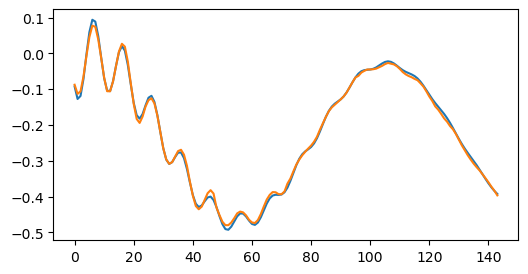

In [8]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [14]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=-0.445541, valid=-0.416756, test=-0.444008
	validation loss decreased (inf -> -0.416756), saving model ...
	epoch 2 losses: train=-0.482042, valid=-0.420135, test=-0.452629
	validation loss decreased (-0.416756 -> -0.420135), saving model ...
	epoch 3 losses: train=-0.494156, valid=-0.426481, test=-0.455617
	validation loss decreased (-0.420135 -> -0.426481), saving model ...
	epoch 4 losses: train=-0.501339, valid=-0.431304, test=-0.452004
	validation loss decreased (-0.426481 -> -0.431304), saving model ...
	epoch 5 losses: train=-0.508970, valid=-0.424449, test=-0.437201
	early stopping counter: 1 out of 10
	epoch 6 losses: train=-0.515129, valid=-0.402691, test=-0.420712
	early stopping counter: 2 out of 10
	epoch 7 losses: train=-0.519554, valid=-0.416847, test=-0.422626
	early stopping counter: 3 out of 10
	epoch 8 losses: train=-0.520024, valid=-0.436123, test=-0.374085
	validation loss decreased (-0.431304 -> -0.436123

In [15]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

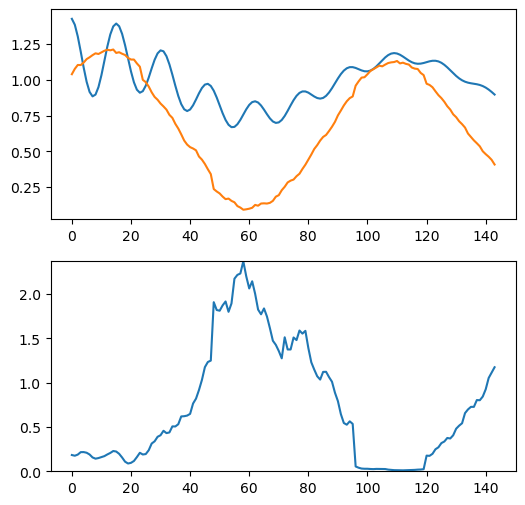

In [16]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [31]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=0.125506, valid=0.023668, test=0.030506
	validation loss decreased (inf -> 0.023668), saving model ...
	epoch 2 losses: train=0.058015, valid=0.018779, test=0.025512
	validation loss decreased (0.023668 -> 0.018779), saving model ...
	epoch 3 losses: train=0.048601, valid=0.017116, test=0.022501
	validation loss decreased (0.018779 -> 0.017116), saving model ...
	epoch 4 losses: train=0.046410, valid=0.016278, test=0.022735
	validation loss decreased (0.017116 -> 0.016278), saving model ...
	epoch 5 losses: train=0.044808, valid=0.016821, test=0.022997
	early stopping counter: 1 out of 10
	epoch 6 losses: train=0.043408, valid=0.016612, test=0.023494
	early stopping counter: 2 out of 10
	epoch 7 losses: train=0.045164, valid=0.016538, test=0.022166
	early stopping counter: 3 out of 10
	epoch 8 losses: train=0.045689, valid=0.016537, test=0.022363
	early stopping counter: 4 out of 10
	epoch 9 losses: train=0.049645, valid=0.017052, tes

In [32]:
model.eval()
_, _, data_loader = dataset.load(data_type='trans')

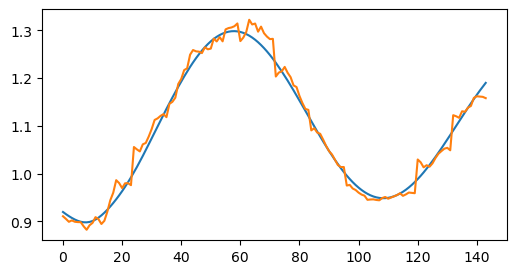

In [34]:
jdata = 7

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [38]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=-0.671978, valid=-0.720560, test=-0.664182
	validation loss decreased (inf -> -0.720560), saving model ...
	epoch 2 losses: train=-0.700658, valid=-0.741463, test=-0.683642
	validation loss decreased (-0.720560 -> -0.741463), saving model ...
	epoch 3 losses: train=-0.717779, valid=-0.751216, test=-0.693444
	validation loss decreased (-0.741463 -> -0.751216), saving model ...
	epoch 4 losses: train=-0.725578, valid=-0.756252, test=-0.698215
	validation loss decreased (-0.751216 -> -0.756252), saving model ...
	epoch 5 losses: train=-0.733423, valid=-0.763974, test=-0.707165
	validation loss decreased (-0.756252 -> -0.763974), saving model ...
	epoch 6 losses: train=-0.741670, valid=-0.769167, test=-0.712824
	validation loss decreased (-0.763974 -> -0.769167), saving model ...
	epoch 7 losses: train=-0.745786, valid=-0.774456, test=-0.715436
	validation loss decreased (-0.769167 -> -0.774456), saving model ...
	epoch 8 losses: t

In [39]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

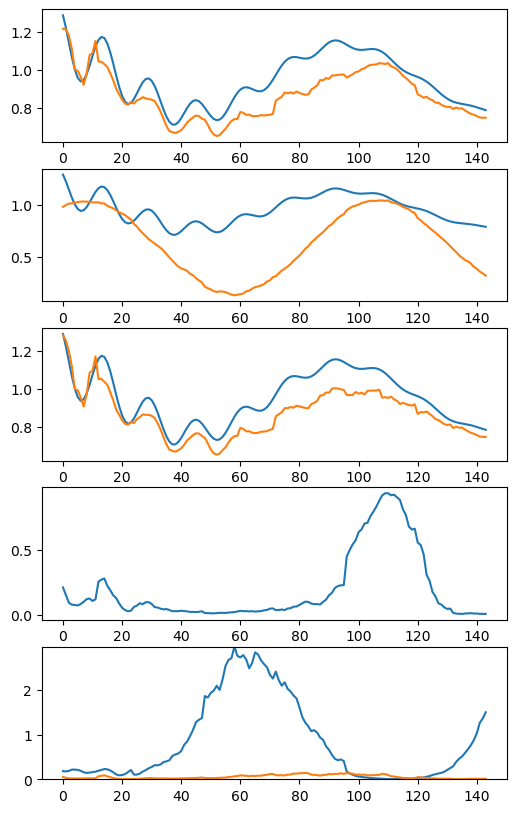

In [40]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break